## 1. Setup & Imports

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import json
import warnings
from typing import Dict, List, Tuple
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from rl_system import PortfolioEnv, PortfolioMonitor

# Plotting setup
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

%matplotlib inline

print("✓ All imports successful")

✓ All imports successful


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 2. Configuration

In [2]:
# Paths
DATA_DIR = project_root / 'data' / 'processed'
MODELS_DIR = project_root / 'models' / 'baseline'
OUTPUT_DIR = project_root / 'results' / 'backtests'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Backtest parameters
INITIAL_CAPITAL = 100000.0
TRANSACTION_COST = 0.00025  # 2.5 bps
MAX_WEIGHT_PER_ASSET = 0.4  # 40% max
REBALANCE_FREQUENCY = 4  # Monthly (every 4 weeks)

# Risk-free rate for Sharpe calculation (annualized)
RISK_FREE_RATE = 0.04  # 4% annual

print(f"Data directory: {DATA_DIR}")
print(f"Models directory: {MODELS_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"\nBacktest Configuration:")
print(f"  Initial capital: ${INITIAL_CAPITAL:,.0f}")
print(f"  Transaction cost: {TRANSACTION_COST*10000:.1f} bps")
print(f"  Max weight per asset: {MAX_WEIGHT_PER_ASSET:.0%}")
print(f"  Rebalance frequency: Every {REBALANCE_FREQUENCY} weeks")
print(f"  Risk-free rate: {RISK_FREE_RATE:.1%} annual")

Data directory: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/data/processed
Models directory: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/models/baseline
Output directory: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/backtests

Backtest Configuration:
  Initial capital: $100,000
  Transaction cost: 2.5 bps
  Max weight per asset: 40%
  Rebalance frequency: Every 4 weeks
  Risk-free rate: 4.0% annual


## 3. Load Data & Metadata

In [3]:
# Load test data
print("Loading test data...")
test_df = pd.read_parquet(DATA_DIR / 'test.parquet')

# Load metadata
with open(DATA_DIR / 'metadata.json', 'r') as f:
    metadata = json.load(f)

feature_cols = metadata['feature_cols']
tickers = metadata['tickers']
n_assets = len(tickers)

# Data summary
print(f"\n{'='*80}")
print("TEST DATA SUMMARY")
print(f"{'='*80}")
print(f"\nShape: {test_df.shape}")
print(f"Tickers: {tickers}")
print(f"Number of assets: {n_assets}")
print(f"Number of features: {len(feature_cols)}")
print(f"\nDate range:")
print(f"  Start: {test_df['date'].min().date()}")
print(f"  End: {test_df['date'].max().date()}")
print(f"  Unique dates: {test_df['date'].nunique()}")
print(f"  Duration: ~{test_df['date'].nunique() / 52:.1f} years")

# Verify no missing values in critical columns
print(f"\nData Integrity:")
print(f"  Missing values: {test_df.isnull().sum().sum()}")
print(f"  Samples per ticker: {len(test_df) / n_assets:.0f}")

# Display sample
print(f"\nSample data (first 3 rows):")
display(test_df.head(3))

print("\n✓ Test data loaded successfully")

Loading test data...

TEST DATA SUMMARY

Shape: (427, 156)
Tickers: ['NVDA', 'MU', 'AAPL', 'AMD', 'ASML', 'MSFT', 'GOOG']
Number of assets: 7
Number of features: 149

Date range:
  Start: 2024-09-04
  End: 2025-10-29
  Unique dates: 61
  Duration: ~1.2 years

Data Integrity:
  Missing values: 0
  Samples per ticker: 61

Sample data (first 3 rows):


,date,open,high,low,close,volume,ticker,treasury_10y,treasury_2y,fed_funds_rate,...,autocorr_1w,autocorr_4w,sin_month,cos_month,sin_dom,cos_dom,returns_52w,bull_market,bear_market,market_concentration
0,2024-09-04,88.360001,90.730003,84.870003,86.391632,91379700,MU,0.86645,0.682002,1.051786,...,0.32043,0.101057,-1.476683,0.063481,1.015956,1.003378,-0.562363,-0.886911,-0.565631,-1.466514
1,2024-09-04,405.910004,416.329987,400.799988,411.113586,83830200,MSFT,0.86645,0.682002,1.051786,...,0.32043,0.101057,-1.476683,0.063481,1.015956,1.003378,-0.562363,-0.886911,-0.565631,-1.466514
2,2024-09-04,158.074997,161.014999,148.199997,149.159973,105008800,GOOG,0.86645,0.682002,1.051786,...,0.32043,0.101057,-1.476683,0.063481,1.015956,1.003378,-0.562363,-0.886911,-0.565631,-1.466514



✓ Test data loaded successfully


## 4. Load Trained Models

In [4]:
# Load fold results to find best model
fold_results_path = MODELS_DIR / 'fold_results.csv'

if fold_results_path.exists():
    fold_results = pd.read_csv(fold_results_path)
    print("Fold Results from Training:")
    display(fold_results[['fold_idx', 'val_sharpe_ratio', 'val_total_return', 
                          'best_val_sharpe', 'n_train_episodes']])
    
    # Select best model (highest validation Sharpe)
    best_fold_idx = fold_results.loc[fold_results['best_val_sharpe'].idxmax(), 'fold_idx']
    best_val_sharpe = fold_results.loc[fold_results['best_val_sharpe'].idxmax(), 'best_val_sharpe']
    
    print(f"\n{'='*80}")
    print(f"SELECTED MODEL: Fold {int(best_fold_idx)} (Val Sharpe: {best_val_sharpe:.3f})")
    print(f"{'='*80}")
    
    # Load best model
    best_model_path = MODELS_DIR / f"fold_{int(best_fold_idx)}" / "best_model.zip"
    
    if best_model_path.exists():
        print(f"\nLoading model from: {best_model_path}")
        rl_model = PPO.load(best_model_path)
        print("✓ RL model loaded successfully")
    else:
        print(f"\n⚠️  Model not found: {best_model_path}")
        print("Please ensure training has been completed.")
        rl_model = None
else:
    print(f"⚠️  Fold results not found: {fold_results_path}")
    print("Please run 02_train_baseline.ipynb first.")
    fold_results = None
    rl_model = None

Fold Results from Training:


,fold_idx,val_sharpe_ratio,val_total_return,best_val_sharpe,n_train_episodes
0,0,0.478955,0.216594,1.162957,2156
1,1,0.125288,0.098074,0.452366,1434
2,2,1.015228,0.682524,1.432960,865



SELECTED MODEL: Fold 2 (Val Sharpe: 1.433)

Loading model from: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/models/baseline/fold_2/best_model.zip
✓ RL model loaded successfully


## 5. Baseline Strategy Implementations

In [5]:
class BaselineStrategy:
    """Base class for baseline strategies."""
    
    def __init__(self, name: str, tickers: List[str], 
                 transaction_cost: float = 0.00025,
                 max_weight: float = 0.4):
        self.name = name
        self.tickers = tickers
        self.n_assets = len(tickers)
        self.transaction_cost = transaction_cost
        self.max_weight = max_weight
        
    def calculate_weights(self, data: pd.DataFrame, current_step: int) -> np.ndarray:
        """Calculate portfolio weights. Must be implemented by subclasses."""
        raise NotImplementedError
        
    def normalize_weights(self, weights: np.ndarray) -> np.ndarray:
        """Normalize weights to sum to 1 and respect max constraint."""
        # Clip to max weight
        weights = np.clip(weights, 0, self.max_weight)
        # Normalize to sum to 1
        if weights.sum() > 0:
            weights = weights / weights.sum()
        else:
            # Fallback to equal weight
            weights = np.ones(self.n_assets) / self.n_assets
        return weights


class EqualWeightStrategy(BaselineStrategy):
    """Equal weight (1/N) strategy."""
    
    def __init__(self, *args, **kwargs):
        super().__init__("Equal Weight", *args, **kwargs)
        
    def calculate_weights(self, data: pd.DataFrame, current_step: int) -> np.ndarray:
        return np.ones(self.n_assets) / self.n_assets


class BuyHoldStrategy(BaselineStrategy):
    """Buy and hold - no rebalancing."""
    
    def __init__(self, *args, **kwargs):
        super().__init__("Buy & Hold", *args, **kwargs)
        self.initial_weights = None
        
    def calculate_weights(self, data: pd.DataFrame, current_step: int) -> np.ndarray:
        if self.initial_weights is None:
            # Set initial equal weights
            self.initial_weights = np.ones(self.n_assets) / self.n_assets
        # Return initial weights (will drift naturally with returns)
        return self.initial_weights


class RiskParityStrategy(BaselineStrategy):
    """Risk parity - weight inversely to volatility."""
    
    def __init__(self, lookback: int = 12, *args, **kwargs):
        super().__init__("Risk Parity", *args, **kwargs)
        self.lookback = lookback
        
    def calculate_weights(self, data: pd.DataFrame, current_step: int) -> np.ndarray:
        if current_step < self.lookback:
            # Not enough history - use equal weights
            return np.ones(self.n_assets) / self.n_assets
        
        # Get historical returns for volatility calculation
        dates = sorted(data['date'].unique())
        lookback_dates = dates[max(0, current_step-self.lookback):current_step]
        
        volatilities = []
        for ticker in self.tickers:
            ticker_data = data[(data['ticker'] == ticker) & 
                              (data['date'].isin(lookback_dates))]
            if len(ticker_data) > 1:
                returns = ticker_data['close'].pct_change().dropna()
                vol = returns.std()
                volatilities.append(vol if vol > 0 else 1.0)
            else:
                volatilities.append(1.0)
        
        # Weight inversely to volatility
        inv_vol = 1.0 / np.array(volatilities)
        weights = inv_vol / inv_vol.sum()
        
        return self.normalize_weights(weights)


class MomentumStrategy(BaselineStrategy):
    """Momentum - overweight assets with highest recent returns."""
    
    def __init__(self, lookback: int = 12, *args, **kwargs):
        super().__init__("Momentum", *args, **kwargs)
        self.lookback = lookback
        
    def calculate_weights(self, data: pd.DataFrame, current_step: int) -> np.ndarray:
        if current_step < self.lookback:
            return np.ones(self.n_assets) / self.n_assets
        
        dates = sorted(data['date'].unique())
        lookback_dates = dates[max(0, current_step-self.lookback):current_step]
        
        returns = []
        for ticker in self.tickers:
            ticker_data = data[(data['ticker'] == ticker) & 
                              (data['date'].isin(lookback_dates))]
            if len(ticker_data) > 1:
                # Total return over lookback period
                total_return = (ticker_data['close'].iloc[-1] / 
                               ticker_data['close'].iloc[0]) - 1
                returns.append(total_return)
            else:
                returns.append(0.0)
        
        # Convert to positive weights (add offset if needed)
        returns = np.array(returns)
        if returns.min() < 0:
            returns = returns - returns.min() + 0.01
        
        weights = returns / returns.sum()
        return self.normalize_weights(weights)


class MinimumVarianceStrategy(BaselineStrategy):
    """Minimum variance portfolio."""
    
    def __init__(self, lookback: int = 12, *args, **kwargs):
        super().__init__("Min Variance", *args, **kwargs)
        self.lookback = lookback
        
    def calculate_weights(self, data: pd.DataFrame, current_step: int) -> np.ndarray:
        if current_step < self.lookback:
            return np.ones(self.n_assets) / self.n_assets
        
        dates = sorted(data['date'].unique())
        lookback_dates = dates[max(0, current_step-self.lookback):current_step]
        
        # Build returns matrix
        returns_matrix = []
        for ticker in self.tickers:
            ticker_data = data[(data['ticker'] == ticker) & 
                              (data['date'].isin(lookback_dates))]
            if len(ticker_data) > 1:
                rets = ticker_data['close'].pct_change().dropna().values
                returns_matrix.append(rets)
            else:
                returns_matrix.append(np.zeros(len(lookback_dates)-1))
        
        returns_matrix = np.array(returns_matrix).T  # Time × Assets
        
        # Calculate covariance matrix
        cov_matrix = np.cov(returns_matrix.T)
        
        # Add small regularization for numerical stability
        cov_matrix += np.eye(self.n_assets) * 1e-5
        
        # Solve for minimum variance weights: min w'Cw s.t. w'1=1
        # Solution: w = (C^-1 * 1) / (1' * C^-1 * 1)
        try:
            inv_cov = np.linalg.inv(cov_matrix)
            ones = np.ones(self.n_assets)
            weights = inv_cov @ ones / (ones @ inv_cov @ ones)
            weights = np.abs(weights)  # Ensure positive
        except:
            # Fallback to equal weights if inversion fails
            weights = np.ones(self.n_assets) / self.n_assets
        
        return self.normalize_weights(weights)


print("✓ Baseline strategies implemented")
print(f"  - {EqualWeightStrategy.__name__}")
print(f"  - {BuyHoldStrategy.__name__}")
print(f"  - {RiskParityStrategy.__name__}")
print(f"  - {MomentumStrategy.__name__}")
print(f"  - {MinimumVarianceStrategy.__name__}")

✓ Baseline strategies implemented
  - EqualWeightStrategy
  - BuyHoldStrategy
  - RiskParityStrategy
  - MomentumStrategy
  - MinimumVarianceStrategy


## 6. Backtest Execution Functions

In [6]:
def backtest_rl_agent(model, test_data: pd.DataFrame, 
                      feature_cols: List[str], tickers: List[str],
                      rebalance_freq: int = 4) -> Dict:
    """
    Backtest RL agent on test data.
    
    Returns:
        Dictionary with trajectory data and final stats
    """
    print(f"\nRunning RL Agent backtest...")
    
    # Create test environment with legacy obs for old models
    def make_test_env():
        env = PortfolioEnv(
            data=test_data.copy(),
            feature_cols=feature_cols,
            tickers=tickers,
            rebalance_frequency=rebalance_freq,
            transaction_cost=TRANSACTION_COST,
            max_weight_per_asset=MAX_WEIGHT_PER_ASSET,
            reward_lookback=12,
            initial_capital=INITIAL_CAPITAL,
            use_legacy_obs=False,
            seed=42
        )
        return PortfolioMonitor(env)
    
    test_env = DummyVecEnv([make_test_env])
    
    # Run backtest
    obs = test_env.reset()
    done = False
    
    trajectory = {
        'weights': [],
        'portfolio_values': [],
        'returns': [],
        'actions': [],
        'dates': []
    }
    
    step_count = 0
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, info = test_env.step(action)
        
        # Get current state from environment
        env_unwrapped = test_env.envs[0]
        while hasattr(env_unwrapped, 'env'):
            env_unwrapped = env_unwrapped.env
        
        trajectory['weights'].append(env_unwrapped.weights.copy())
        trajectory['portfolio_values'].append(env_unwrapped.portfolio_value)
        trajectory['actions'].append(action[0].copy())
        
        if len(env_unwrapped.portfolio_returns) > 0:
            trajectory['returns'].append(env_unwrapped.portfolio_returns[-1])
        
        if env_unwrapped.current_step < len(env_unwrapped.dates):
            trajectory['dates'].append(env_unwrapped.dates[env_unwrapped.current_step])
        
        step_count += 1
        
        if done[0]:
            done = True
            # Get final stats
            if 'portfolio_stats' in info[0]:
                final_stats = info[0]['portfolio_stats']
            else:
                final_stats = env_unwrapped.get_portfolio_stats()
    
    print(f"  Completed {step_count} steps")
    print(f"  Final portfolio value: ${final_stats['portfolio_value']:,.2f}")
    
    return {
        'trajectory': trajectory,
        'stats': final_stats,
        'name': 'RL Agent'
    }


def backtest_baseline_strategy(strategy: BaselineStrategy, 
                               test_data: pd.DataFrame,
                               rebalance_freq: int = 4) -> Dict:
    """
    Backtest a baseline strategy on test data.
    
    Returns:
        Dictionary with trajectory data and final stats
    """
    print(f"\nRunning {strategy.name} backtest...")
    
    dates = sorted(test_data['date'].unique())
    n_periods = len(dates)
    
    # Initialize
    portfolio_value = INITIAL_CAPITAL
    weights = strategy.calculate_weights(test_data, 0)
    
    trajectory = {
        'weights': [weights.copy()],
        'portfolio_values': [portfolio_value],
        'returns': [],
        'dates': [dates[0]]
    }
    
    # Run backtest
    for step in range(n_periods - 1):
        current_date = dates[step]
        next_date = dates[step + 1]
        
        # Calculate asset returns
        asset_returns = []
        for ticker in strategy.tickers:
            curr_price = test_data[(test_data['date'] == current_date) & 
                                   (test_data['ticker'] == ticker)]['close'].iloc[0]
            next_price = test_data[(test_data['date'] == next_date) & 
                                   (test_data['ticker'] == ticker)]['close'].iloc[0]
            asset_returns.append(np.log(next_price / curr_price))
        
        asset_returns = np.array(asset_returns)
        
        # Calculate portfolio return
        portfolio_return = np.sum(weights * asset_returns)
        
        # Check if should rebalance
        should_rebalance = (step % rebalance_freq == 0) and (strategy.name != "Buy & Hold")
        
        if should_rebalance:
            new_weights = strategy.calculate_weights(test_data, step + 1)
            transaction_cost = strategy.transaction_cost * np.sum(np.abs(new_weights - weights))
            portfolio_return -= transaction_cost
            weights = new_weights
        else:
            # Weights drift naturally with returns (for Buy & Hold)
            if strategy.name == "Buy & Hold" and step > 0:
                # Update weights based on value changes
                weights = weights * np.exp(asset_returns)
                weights = weights / weights.sum()
        
        # Update portfolio value
        portfolio_value *= np.exp(portfolio_return)
        
        # Store trajectory
        trajectory['returns'].append(portfolio_return)
        trajectory['weights'].append(weights.copy())
        trajectory['portfolio_values'].append(portfolio_value)
        trajectory['dates'].append(next_date)
    
    # Calculate final stats
    returns = np.array(trajectory['returns'])
    total_return = (portfolio_value / INITIAL_CAPITAL) - 1.0
    
    if len(returns) >= 2:
        mean_return = np.mean(returns)
        std_return = np.std(returns, ddof=1) + 1e-8
        sharpe = (mean_return / std_return) * np.sqrt(52)
    else:
        sharpe = 0.0
    
    volatility = np.std(returns) * np.sqrt(52)
    
    # Max drawdown
    cum_returns = np.exp(np.cumsum(returns))
    running_max = np.maximum.accumulate(cum_returns)
    drawdown = (cum_returns - running_max) / running_max
    max_drawdown = np.min(drawdown)
    
    final_stats = {
        'total_return': total_return,
        'sharpe_ratio': sharpe,
        'volatility': volatility,
        'max_drawdown': max_drawdown,
        'portfolio_value': portfolio_value
    }
    
    print(f"  Final portfolio value: ${portfolio_value:,.2f}")
    print(f"  Total return: {total_return:.2%}")
    print(f"  Sharpe ratio: {sharpe:.3f}")
    
    return {
        'trajectory': trajectory,
        'stats': final_stats,
        'name': strategy.name
    }


print("✓ Backtest functions defined")

✓ Backtest functions defined


## 7. Run All Backtests

In [7]:
print("="*80)
print("EXECUTING BACKTESTS")
print("="*80)

# Store all results
backtest_results = {}

# 1. Backtest RL Agent (if model loaded)
if rl_model is not None:
    try:
        rl_result = backtest_rl_agent(
            rl_model, 
            test_df, 
            feature_cols, 
            tickers,
            REBALANCE_FREQUENCY
        )
        backtest_results['RL Agent'] = rl_result
    except Exception as e:
        print(f"\n⚠️  RL Agent backtest failed: {e}")
        import traceback
        traceback.print_exc()
else:
    print("\n⚠️  Skipping RL Agent (model not loaded)")

# 2. Backtest baseline strategies
baseline_strategies = [
    EqualWeightStrategy(tickers, TRANSACTION_COST, MAX_WEIGHT_PER_ASSET),
    BuyHoldStrategy(tickers, TRANSACTION_COST, MAX_WEIGHT_PER_ASSET),
    RiskParityStrategy(12, tickers, TRANSACTION_COST, MAX_WEIGHT_PER_ASSET),
    MomentumStrategy(12, tickers, TRANSACTION_COST, MAX_WEIGHT_PER_ASSET),
    MinimumVarianceStrategy(12, tickers, TRANSACTION_COST, MAX_WEIGHT_PER_ASSET)
]

for strategy in baseline_strategies:
    try:
        result = backtest_baseline_strategy(strategy, test_df, REBALANCE_FREQUENCY)
        backtest_results[strategy.name] = result
    except Exception as e:
        print(f"\n⚠️  {strategy.name} backtest failed: {e}")
        import traceback
        traceback.print_exc()

print("\n" + "="*80)
print(f"BACKTESTS COMPLETE: {len(backtest_results)} strategies tested")
print("="*80)

EXECUTING BACKTESTS

Running RL Agent backtest...

⚠️  RL Agent backtest failed: PortfolioEnv.__init__() got an unexpected keyword argument 'use_legacy_obs'

Running Equal Weight backtest...
  Final portfolio value: $167,110.42
  Total return: 67.11%
  Sharpe ratio: 1.344

Running Buy & Hold backtest...


Traceback (most recent call last):
  File "/var/folders/lj/jghsddqd5mxbhxdb6mwg7qcw0000gn/T/ipykernel_22709/542746748.py", line 11, in <module>
    rl_result = backtest_rl_agent(
                ^^^^^^^^^^^^^^^^^^
  File "/var/folders/lj/jghsddqd5mxbhxdb6mwg7qcw0000gn/T/ipykernel_22709/429042921.py", line 28, in backtest_rl_agent
    test_env = DummyVecEnv([make_test_env])
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/nataliamarko/miniconda3/envs/demand_forecast_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/dummy_vec_env.py", line 31, in __init__
    self.envs = [_patch_env(fn()) for fn in env_fns]
                            ^^^^
  File "/var/folders/lj/jghsddqd5mxbhxdb6mwg7qcw0000gn/T/ipykernel_22709/429042921.py", line 14, in make_test_env
    env = PortfolioEnv(
          ^^^^^^^^^^^^^
TypeError: PortfolioEnv.__init__() got an unexpected keyword argument 'use_legacy_obs'


  Final portfolio value: $162,110.83
  Total return: 62.11%
  Sharpe ratio: 1.275

Running Risk Parity backtest...
  Final portfolio value: $148,890.73
  Total return: 48.89%
  Sharpe ratio: 1.178

Running Momentum backtest...
  Final portfolio value: $163,768.94
  Total return: 63.77%
  Sharpe ratio: 1.337

Running Min Variance backtest...
  Final portfolio value: $160,052.02
  Total return: 60.05%
  Sharpe ratio: 1.339

BACKTESTS COMPLETE: 5 strategies tested


## 8. Performance Metrics & Summary

Calculate comprehensive metrics and create summary table.

In [8]:
# Create summary from stats already calculated
summary_data = []

for name, result in backtest_results.items():
    stats = result['stats']
    trajectory = result['trajectory']
    
    # Add additional metrics
    if len(trajectory['weights']) > 1:
        weights_array = np.array(trajectory['weights'])
        weight_changes = np.abs(np.diff(weights_array, axis=0)).sum(axis=1)
        avg_turnover = np.mean(weight_changes)
    else:
        avg_turnover = 0.0
    
    returns = np.array(trajectory['returns'])
    win_rate = (returns > 0).sum() / len(returns) if len(returns) > 0 else 0.0
    
    summary_data.append({
        'Strategy': name,
        'Total Return': stats['total_return'],
        'Sharpe Ratio': stats['sharpe_ratio'],
        'Volatility': stats['volatility'],
        'Max Drawdown': stats['max_drawdown'],
        'Final Value': stats['portfolio_value'],
        'Avg Turnover': avg_turnover,
        'Win Rate': win_rate
    })

summary_df = pd.DataFrame(summary_data)

print("="*80)
print("PERFORMANCE SUMMARY - OUT-OF-SAMPLE TEST PERIOD")
print("="*80)
display(summary_df.style.format({
    'Total Return': '{:.2%}',
    'Sharpe Ratio': '{:.3f}',
    'Volatility': '{:.2%}',
    'Max Drawdown': '{:.2%}',
    'Final Value': '${:,.0f}',
    'Avg Turnover': '{:.3f}',
    'Win Rate': '{:.1%}'
}).background_gradient(subset=['Sharpe Ratio'], cmap='RdYlGn'))

# Export summary
summary_df.to_csv(OUTPUT_DIR / 'backtest_summary.csv', index=False)
print(f"\n✓ Summary saved: {OUTPUT_DIR / 'backtest_summary.csv'}")

PERFORMANCE SUMMARY - OUT-OF-SAMPLE TEST PERIOD


,Strategy,Total Return,Sharpe Ratio,Volatility,Max Drawdown,Final Value,Avg Turnover,Win Rate
0,Equal Weight,67.11%,1.344,32.82%,-29.65%,"$167,110",0.000,65.0%
1,Buy & Hold,62.11%,1.275,32.57%,-31.26%,"$162,111",0.033,63.3%
2,Risk Parity,48.89%,1.178,29.04%,-28.47%,"$148,891",0.038,60.0%
3,Momentum,63.77%,1.337,31.71%,-29.20%,"$163,769",0.101,56.7%
4,Min Variance,60.05%,1.339,30.19%,-28.74%,"$160,052",0.096,60.0%



✓ Summary saved: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/backtests/backtest_summary.csv


		8 weeks look back and multicomponents reqward
				Strategy	Total Return	Sharpe Ratio	Volatility	Max Drawdown	Final Value	Avg Turnover	Win Rate
			0	RL Agent	19.59%	0.549	32.25%	-27.07%	$119,593	0.187	56.9%
			1	Equal Weight	26.45%	0.923	25.18%	-20.00%	$126,448	0.000	59.6%
			2	Buy & Hold	29.17%	0.951	26.65%	-20.51%	$129,169	0.031	57.7%
			3	Risk Parity	30.77%	1.185	22.43%	-17.82%	$130,772	0.030	63.5%
			4	Momentum	33.87%	1.098	26.31%	-18.54%	$133,869	0.090	55.8%
			5	Min Variance	33.45%	1.288	22.19%	-16.66%	$133,450	0.116	63.5%


## 9. Visualization: Cumulative Returns

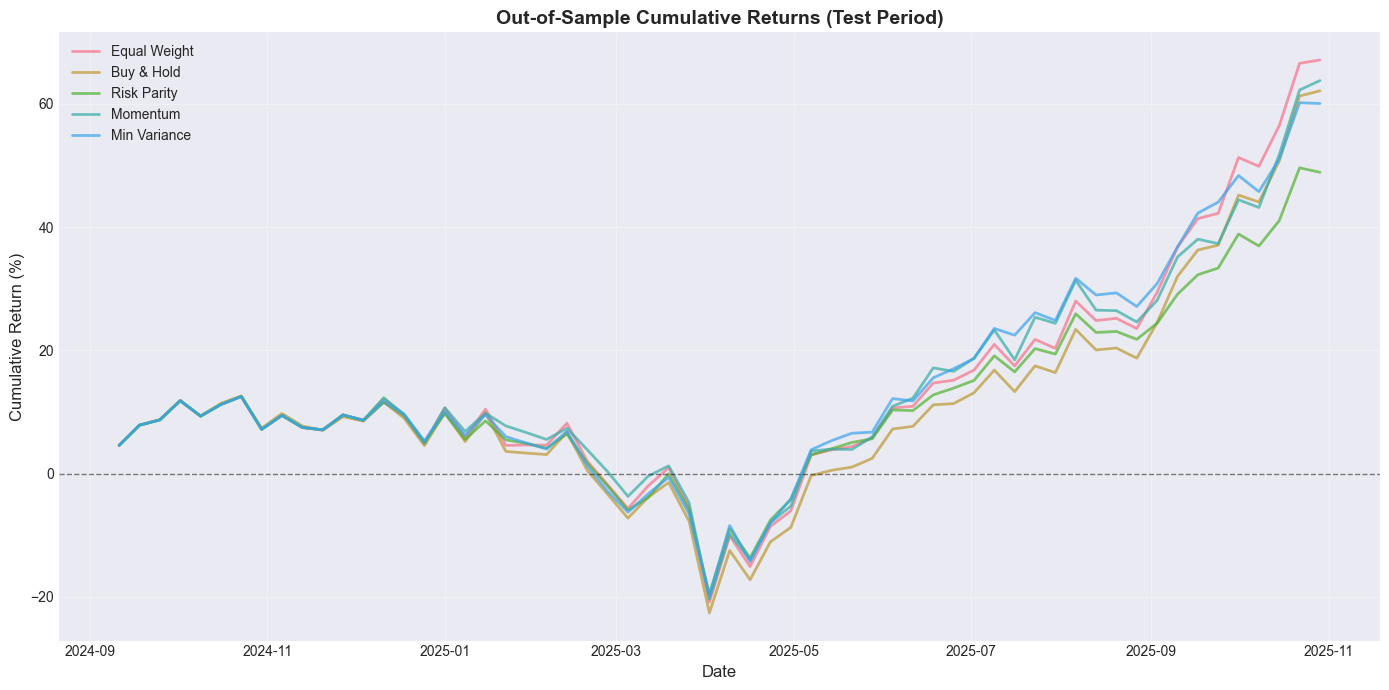

✓ Plot saved: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/backtests/cumulative_returns.png


In [9]:
fig, ax = plt.subplots(figsize=(14, 7))

for name, result in backtest_results.items():
    returns = np.array(result['trajectory']['returns'])
    dates = result['trajectory']['dates'][1:]  # Skip first (no return yet)
    
    cum_returns = (np.exp(np.cumsum(returns)) - 1) * 100
    
    linewidth = 3 if name == 'RL Agent' else 2
    alpha = 1.0 if name == 'RL Agent' else 0.7
    
    ax.plot(dates, cum_returns, label=name, linewidth=linewidth, alpha=alpha)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return (%)', fontsize=12)
ax.set_title('Out-of-Sample Cumulative Returns (Test Period)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cumulative_returns.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Plot saved: {OUTPUT_DIR / 'cumulative_returns.png'}")

## 10. Visualization: RL Agent Portfolio Weights

In [10]:
if 'RL Agent' in backtest_results:
    rl_trajectory = backtest_results['RL Agent']['trajectory']
    weights = np.array(rl_trajectory['weights'])
    dates = rl_trajectory['dates']
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Stacked area chart
    ax.stackplot(dates, weights.T, labels=tickers, alpha=0.8)
    
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Portfolio Weight', fontsize=12)
    ax.set_title('RL Agent: Portfolio Weights Over Time', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add constraint line
    ax.axhline(y=MAX_WEIGHT_PER_ASSET, color='red', linestyle='--', 
               linewidth=2, label=f'Max Weight ({MAX_WEIGHT_PER_ASSET:.0%})', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'rl_weights_evolution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Plot saved: {OUTPUT_DIR / 'rl_weights_evolution.png'}")
    
    # Print average weights
    avg_weights = weights.mean(axis=0)
    print("\nAverage Portfolio Weights:")
    for ticker, weight in zip(tickers, avg_weights):
        print(f"  {ticker}: {weight:.1%}")
else:
    print("⚠️  RL Agent results not available")

⚠️  RL Agent results not available


## 11. Conclusions & Recommendations

### Key Findings
Review the summary table and plots above to draw conclusions:

1. **Did the RL agent outperform baselines?**
   - Compare Sharpe ratios
   - Check if differences are meaningful

2. **Risk-adjusted performance**
   - Sharpe ratio comparison
   - Drawdown analysis

3. **Trading efficiency**
   - Turnover levels
   - Transaction cost impact

### Next Steps
Based on results, consider:
- Hyperparameter tuning
- Alternative reward functions
- Different network architectures
- Additional features
- Ensemble methods

## 12. Export Results

In [11]:
# Export detailed results
print("Exporting results...")

# 1. Export trajectories
for name, result in backtest_results.items():
    trajectory = result['trajectory']
    
    # Create DataFrame
    traj_df = pd.DataFrame({
        'date': trajectory['dates'][1:],  # Skip first
        'return': trajectory['returns'],
        'portfolio_value': trajectory['portfolio_values'][1:]  # Skip first
    })
    
    # Add weights
    weights_df = pd.DataFrame(
        trajectory['weights'][1:],  # Skip first
        columns=[f'weight_{ticker}' for ticker in tickers]
    )
    
    traj_df = pd.concat([traj_df, weights_df], axis=1)
    
    # Save
    safe_name = name.replace(' ', '_').replace('&', 'and').lower()
    traj_df.to_csv(OUTPUT_DIR / f'trajectory_{safe_name}.csv', index=False)
    print(f"  ✓ {name}: trajectory_{safe_name}.csv")

# 2. Export comparison metrics
summary_df.to_csv(OUTPUT_DIR / 'metrics_comparison.csv', index=False)
print(f"  ✓ Metrics comparison: metrics_comparison.csv")

# 3. Create summary report
report = {
    'test_period': {
        'start': str(test_df['date'].min().date()),
        'end': str(test_df['date'].max().date()),
        'n_weeks': test_df['date'].nunique()
    },
    'configuration': {
        'initial_capital': INITIAL_CAPITAL,
        'transaction_cost_bps': TRANSACTION_COST * 10000,
        'max_weight_per_asset': MAX_WEIGHT_PER_ASSET,
        'rebalance_frequency_weeks': REBALANCE_FREQUENCY
    },
    'strategies_tested': list(backtest_results.keys()),
    'best_sharpe': {
        'strategy': summary_df.loc[summary_df['Sharpe Ratio'].idxmax(), 'Strategy'],
        'value': float(summary_df['Sharpe Ratio'].max())
    },
    'best_return': {
        'strategy': summary_df.loc[summary_df['Total Return'].idxmax(), 'Strategy'],
        'value': float(summary_df['Total Return'].max())
    }
}

with open(OUTPUT_DIR / 'backtest_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print(f"  ✓ Summary report: backtest_report.json")

print(f"\n{'='*80}")
print(f"ALL RESULTS EXPORTED TO: {OUTPUT_DIR}")
print(f"{'='*80}")
print("\n✓ Backtest analysis complete!")

Exporting results...
  ✓ Equal Weight: trajectory_equal_weight.csv
  ✓ Buy & Hold: trajectory_buy_and_hold.csv
  ✓ Risk Parity: trajectory_risk_parity.csv
  ✓ Momentum: trajectory_momentum.csv
  ✓ Min Variance: trajectory_min_variance.csv
  ✓ Metrics comparison: metrics_comparison.csv
  ✓ Summary report: backtest_report.json

ALL RESULTS EXPORTED TO: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/backtests

✓ Backtest analysis complete!
